# Distribution Plots

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Histogram
`sns.histplot()`

In [2]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


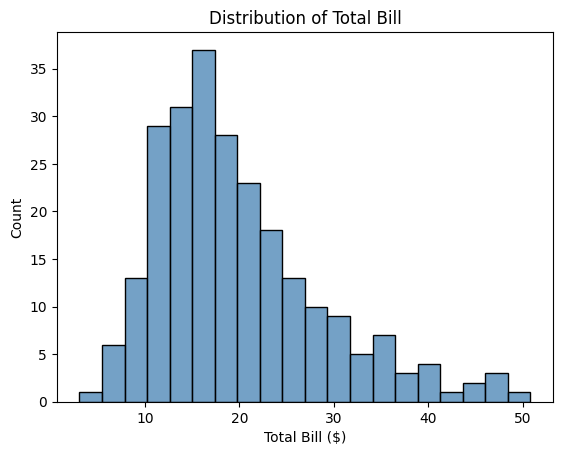

In [3]:
sns.histplot(data=df, x='total_bill', bins=20,
             color='steelblue', edgecolor='black')

plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Count")
plt.show()

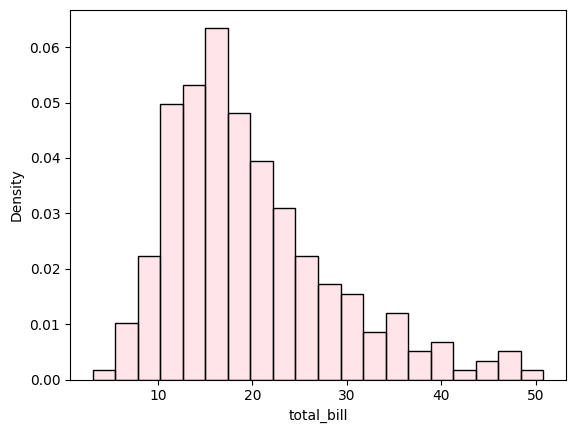

In [7]:
sns.histplot(data=df,
            x='total_bill',
            bins=20,
            color='pink',
            edgecolor='black',
            alpha=0.4,
            stat='density')
plt.show()

### `stat` parameter

|..|..|
|-|-|
|'count'|row count of values(default)|
|'frequency'|count divided by bin width|
|'density'|area sums to 1|
|'probability'|each bar = proportion of total|

---

I tried each but almost every stat looks same.

## 2. KDE plot
`sns.kdeplot()`  
KDE - Kernel Density Estimate, smooth curve showing the shape of distribution

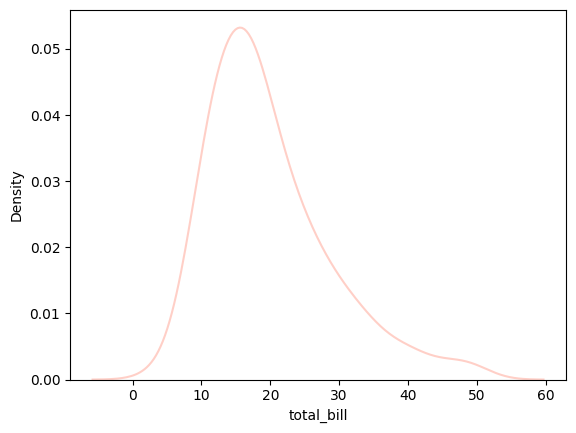

In [8]:
sns.kdeplot(data=df,
           x='total_bill',
           color='tomato',
           alpha=0.3)
plt.show()

### Filling under the Curve

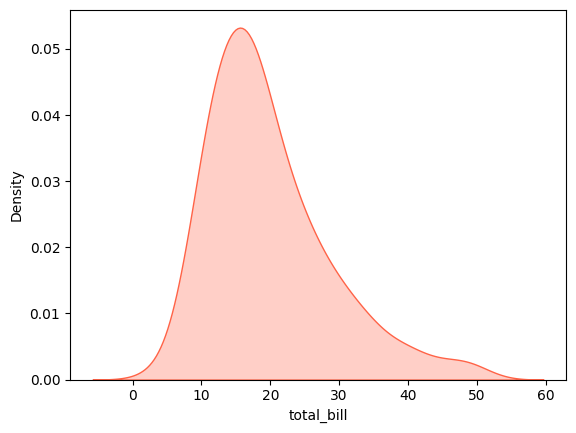

In [12]:
sns.kdeplot(data=df,
            x='total_bill',
           color='tomato',
           fill=True, # This fill area under curve
           alpha=0.3)
plt.show()

## 3. Histogram + KDE
Just pass one extra parameter `kde = True`

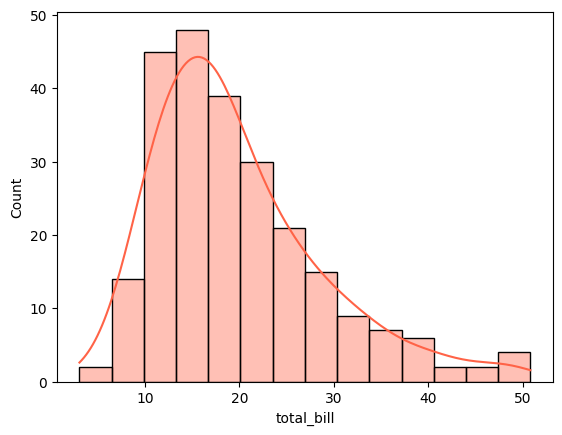

In [13]:
sns.histplot(data=df,
            x='total_bill',
            color='tomato',
            alpha=0.4,
            kde=True)
plt.show()

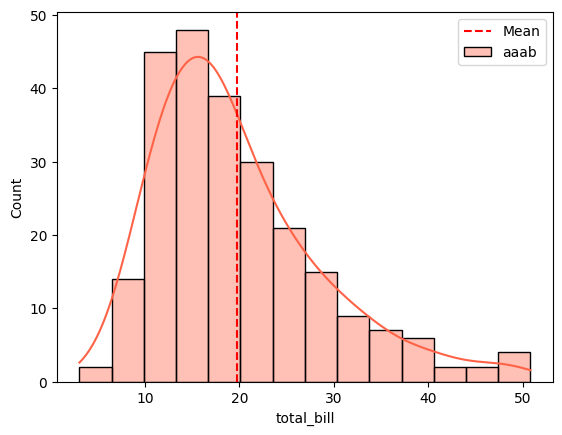

In [20]:
mean = df['total_bill'].mean()
sns.histplot(data=df,
            x='total_bill',
            color='tomato',
            alpha=0.4,
            kde=True,
            label='aaab')
plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

## 4. Distribution with Multiple Categories

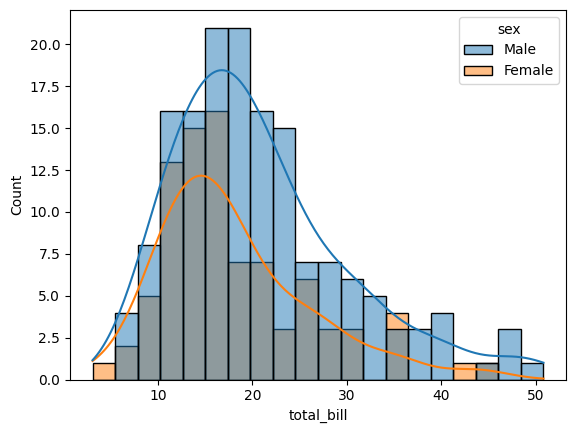

In [5]:
sns.histplot(data=df,
             x='total_bill',
             hue='sex',          # split by gender — one parameter!
             bins=20,
             edgecolor='black',
            kde=True)

plt.show()

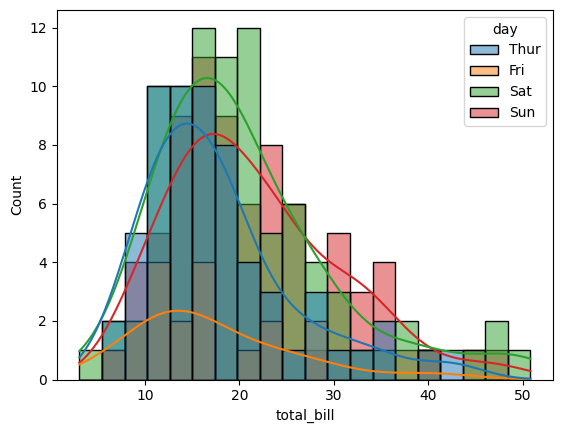

In [6]:
sns.histplot(data=df,
             x='total_bill',
             hue='day',          # split by gender — o ne parameter!
             bins=20,
             edgecolor='black',
            kde=True)

plt.show()

### Comparing multiple columns at once

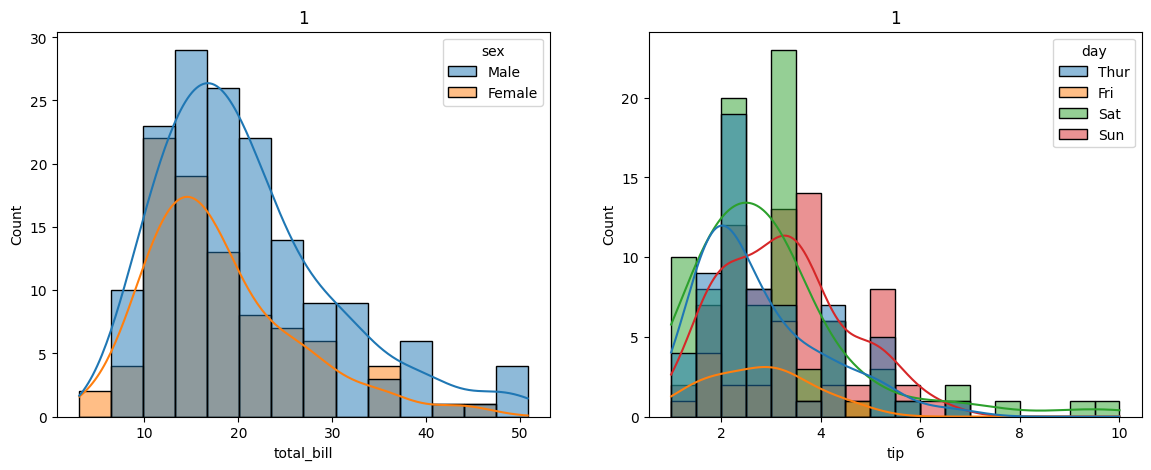

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='total_bill', hue='sex', kde=True, ax=axes[0])
axes[0].set_title('1')
sns.histplot(data=df, x='tip', hue='day', kde=True, ax=axes[1])
axes[1].set_title('1')
plt.show()

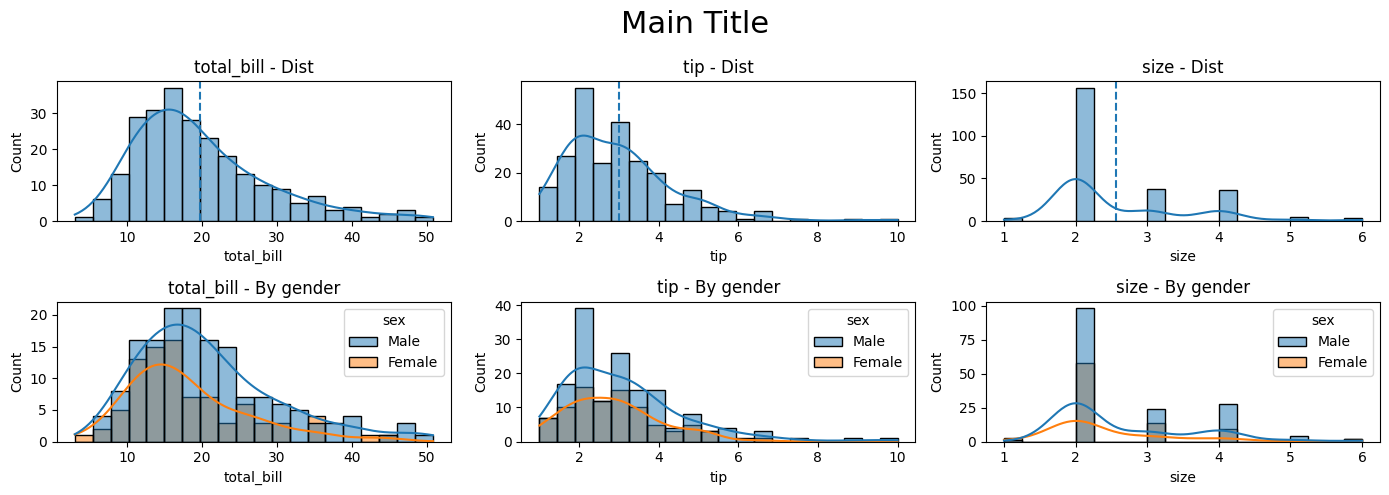

In [17]:
# Full EDA distribution workflow

numeric_col = ['total_bill', 'tip', 'size']

fig, axes = plt.subplots(2, 3, figsize=(14, 5))

for i, col in enumerate(numeric_col):
    sns.histplot(data=df, x=col, bins=20, kde=True, ax=axes[0, i])
    axes[0,i].set_title(f"{col} - Dist")
    axes[0,i].axvline(df[col].mean(), linestyle='--')
    
    sns.histplot(data=df, x=col,hue='sex', bins=20, kde=True, ax=axes[1, i])
    axes[1,i].set_title(f"{col} - By gender")
plt.suptitle('Main Title', fontsize=22)
plt.tight_layout()
plt.show()